In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import io

test_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_V3_0.5_0.2_0.0001_4/scores.npy'
test_scores = np.load(test_scores_path)
test_scores = np.transpose(test_scores, (1, 2, 0))


# 假设 val_scores 是模型的输出，scores 为二维数组
scores = test_scores[:, :, 2]

import plotly.graph_objects as go
import numpy as np

# 假设 val_scores 是模型的输出，scores 为二维数组

# 标准化 scores，将其缩放到 [0, 1] 的范围
scores_min, scores_max = scores.min(), scores.max()
normalized_scores = (scores - scores_min) / (scores_max - scores_min)
normalized_scores = np.fliplr(normalized_scores)

# 生成 x 和 y 坐标
x = np.linspace(0, normalized_scores.shape[1], normalized_scores.shape[1])
y = np.linspace(0, normalized_scores.shape[0], normalized_scores.shape[0])
x, y = np.meshgrid(x, y)

# 使用 Plotly 创建三维图
fig = go.Figure(data=[go.Surface(z=normalized_scores, x=x, y=y, colorscale='Inferno', opacity=1)])

# 添加阈值平面
fig.add_trace(go.Surface(z=0.01 * np.ones_like(normalized_scores), x=x, y=y, colorscale=[[0, 'red'], [1, 'red']], opacity=1))

# 更新布局，设置标题、轴范围和背景颜色
fig.update_layout(
    title="Interactive 3D Surface with Threshold Planes",
    scene=dict(
        
        xaxis=dict(showbackground=False, title="X Axis"),
        yaxis=dict(showbackground=False, title="Y Axis"),
        zaxis=dict(range=[0, 1], showbackground=False, title="Normalized Scores")
    ),
    hovermode='closest'  # 将提示框固定在数据点位置
)
fig.update_traces(hoverinfo='none')  # 隐藏所有提示框
fig.show()




In [ ]:
# 绘制平面图显示score值
plt.figure(figsize=(10, 8))
plt.imshow(np.fliplr(scores), cmap='jet')
plt.imshow(scores, cmap='jet')
plt.colorbar(label='Score')
plt.title('Score')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


# 绘制三种结果的对比图
plt.figure(figsize=(10, 8))

# 创建一个空白图像
result = np.zeros_like(scores)

# 设置不同的像素值来表示不同的区域
gt_mask = val_gt_masks[:, :, 2] == 1  # 使用样本2的真实标签
pred_mask_05 = scores >= 0.5  # 阈值0.5的预测结果  
pred_mask_001 = scores >= 0.2  # 阈值0.01的预测结果

# 用不同的像素值标记不同区域
result[:,:] = 4  # 阈值0.01的区域标记为4
result[pred_mask_001] = 3  # 阈值0.01的区域标记为3
result[gt_mask] = 2  # GT区域标记为1
result[pred_mask_05] = 1  # 阈值0.5的区域标记为2  

# 使用自定义colormap显示结果
colors = ['red', 'yellow', 'blue', 'black']  # 分别对应0,1,2,3
custom_cmap = plt.cm.colors.ListedColormap(colors)

plt.imshow(result, cmap=custom_cmap)
plt.colorbar(ticks=[0, 1, 2, 3], label='类别')
plt.title('分割结果对比')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.show()


# 绘制三种结果的对比图
plt.figure(figsize=(10, 8))

# 创建一个空白图像
result = np.zeros_like(scores)

# 设置不同的像素值来表示不同的区域
gt_mask = val_gt_masks[:, :, 2] == 1  # 使用样本2的真实标签
pred_mask_05 = scores >= 0.5  # 阈值0.5的预测结果  
pred_mask_001 = scores >= 0.1  # 阈值0.01的预测结果

# 用不同的像素值标记不同区域
result[:,:] = 3  # GT区域标记为1
result[gt_mask] = 1  # GT区域标记为1
result[pred_mask_001] = 2  # 阈值0.01的区域标记为3

# 使用自定义colormap显示结果
colors = ['yellow', 'blue','black']  # 分别对应0,1,2,3
custom_cmap = plt.cm.colors.ListedColormap(colors)

plt.imshow(result, cmap=custom_cmap)
plt.colorbar(ticks=[0, 1,2], label='类别')
plt.title('分割结果对比')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 使用样本 2 的预测分数和真实掩码
sample_idx = 2  
scores = val_scores[:, :, sample_idx]
gt_mask = val_gt_masks[:, :, sample_idx]

# 定义阈值范围
# thresholds = np.linspace(0.1, 0.9, 9)  # 从 0.1 到 0.9 取 9 个阈值
thresholds = [0.5]  # 从 0.1 到 0.9 取 9 个阈值

# 初始化子图
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# 遍历阈值
for idx, threshold in enumerate(thresholds):
    # 使用当前阈值生成二值化分割
    pred_mask = scores >= threshold
    
    # # 创建 RGB 图像层
    # rgb_image = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.uint8)
    
    # # 计算真阳性(TP)、假阳性(FP)和假阴性(FN)
    # true_positive = (pred_mask == 1) & (gt_mask == 1)  # 正确预测为1的区域
    # false_positive = (pred_mask == 1) & (gt_mask == 0)  # 错误预测为1的区域(假阳性)
    # false_negative = (pred_mask == 0) & (gt_mask == 1)  # 错误预测为0的区域(假阴性)
    
    # # 正确分割结果用白色显示 (RGB: 255,255,255)
    # rgb_image[true_positive] = [255, 255, 255]
    
    # # 假阳性用蓝色显示 (RGB: 0,0,255)
    # rgb_image[false_positive] = [0, 0, 255]
    
    # # 假阴性用红色显示 (RGB: 255,0,0)
    # rgb_image[false_negative] = [255, 0, 0]
    
    # 显示结果
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    ax.imshow(pred_mask,cmap='gray')
    ax.set_title(f'Threshold: {threshold:.1f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

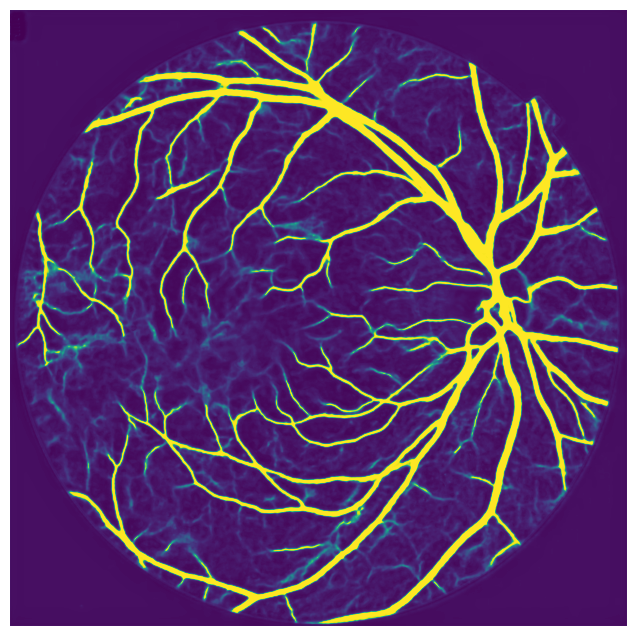

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import io

# 文件路径
scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDice_0.0001_16/scores.npy'
gt_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDice_0.0001_16/gt_masks.npy'
# 读取保存的 numpy 数组文件
gt_masks = np.load(gt_masks_path)  # 加载真实标签数据
scores = np.load(scores_path)      # 加载预测结果数据

# 修改 gt_masks 和 scores 的形状，将最后一个维度转到第三个维度
gt_masks = np.transpose(gt_masks, (1, 2, 0))
scores = np.transpose(scores, (1, 2, 0))
# print("gt_masks 和 scores 文件已成功加载。")
# print(f"gt_masks 的形状: {gt_masks.shape}")
# print(f"scores 的形状: {scores.shape}")

cal_idx = np.arange(0, 15)
val_idx = np.setdiff1d(np.arange(1, scores.shape[2]), cal_idx) # 最后剩下的用于校准集

# 提取校准集的 score 数据
cal_scores = scores[:, :, cal_idx]  # 索引从 0 开始，cal_idx 减去 1
val_scores = scores[:, :, val_idx]  # 索引从 0 开始，cal_idx 减去 1
cal_gt_masks = gt_masks[:, :, cal_idx]  # 索引从 0 开始，cal_idx 减去 1
val_gt_masks = gt_masks[:, :, val_idx]  # 索引从 0 开始，cal_idx 减去 1



fig, axs = plt.subplots(1, 1, figsize=(20, 8))
i = 0  # 仅绘制第一张
predicted_mask = val_scores[:, :, i]  # 应用阈值生成二值掩码
power_mask = np.power(predicted_mask, 0.3)
axs.imshow(power_mask)
axs.axis('off')
plt.show()



In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import io
from matplotlib.colors import ListedColormap

# 文件路径
scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDice_0.0001_16/scores.npy'
gt_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDice_0.0001_16/gt_masks.npy'

# 读取保存的 numpy 数组文件
gt_masks = np.load(gt_masks_path)  # 加载真实标签数据
scores = np.load(scores_path)      # 加载预测结果数据

# 修改 gt_masks 和 scores 的形状，将最后一个维度转到第三个维度
gt_masks = np.transpose(gt_masks, (1, 2, 0))
scores = np.transpose(scores, (1, 2, 0))
print(f"gt_masks 的形状: {gt_masks.shape}")
print(f"scores 的形状: {scores.shape}")

cal_idx = np.arange(0, 15)
val_idx = np.setdiff1d(np.arange(1, scores.shape[2]), cal_idx) # 最后剩下的用于校准集

# 提取校准集的 score 数据
cal_scores = scores[:, :, cal_idx]
val_scores = scores[:, :, val_idx]
cal_gt_masks = gt_masks[:, :, cal_idx]
val_gt_masks = gt_masks[:, :, val_idx]

# 第一个可视化：使用幂律变换的原始概率图
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(10):
    predicted_mask = val_scores[:, :, i]
    power_mask = np.power(predicted_mask, 0.3)
    axs[i//5, i%5].imshow(power_mask, cmap='viridis')
    axs[i//5, i%5].set_title(f"Sample {i+1} - Probability (gamma=0.3)")
    axs[i//5, i%5].axis('off')
plt.tight_layout()
plt.savefig('probability_masks.png')
plt.close()

# 第二个可视化：使用标准阈值的二值掩码
threshold_standard = 0.5
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(10):
    predicted_binary = val_scores[:, :, i] > threshold_standard
    ground_truth = val_gt_masks[:, :, i] > 0.5
    
    # 创建错误可视化掩码：
    # 0: 正确的背景 (TN) - 黑色
    # 1: 正确的前景 (TP) - 白色
    # 2: 假阳性 (FP) - 蓝色
    # 3: 假阴性 (FN) - 红色
    error_mask = np.zeros_like(predicted_binary, dtype=np.uint8)
    
    # 正确的前景 (True Positive)
    error_mask[np.logical_and(predicted_binary, ground_truth)] = 1
    
    # 假阳性 (False Positive) - 预测为前景但实际是背景
    error_mask[np.logical_and(predicted_binary, ~ground_truth)] = 2
    
    # 假阴性 (False Negative) - 预测为背景但实际是前景
    error_mask[np.logical_and(~predicted_binary, ground_truth)] = 3
    
    # 创建自定义色彩映射：黑、白、蓝、红
    colors = ['black', 'white', 'blue', 'red']
    cmap = ListedColormap(colors)
    
    axs[i//5, i%5].imshow(error_mask, cmap=cmap, vmin=0, vmax=3)
    axs[i//5, i%5].set_title(f"Sample {i+1} - Threshold {threshold_standard}")
    axs[i//5, i%5].axis('off')
plt.tight_layout()
plt.savefig('standard_threshold_errors.png')
plt.close()

# 第三个可视化：使用自定义阈值的二值掩码
threshold_custom = 0.013467237820238523
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(10):
    predicted_binary = val_scores[:, :, i] > threshold_custom
    ground_truth = val_gt_masks[:, :, i] > 0.5
    
    # 创建错误可视化掩码
    error_mask = np.zeros_like(predicted_binary, dtype=np.uint8)
    
    # 正确的前景 (True Positive)
    error_mask[np.logical_and(predicted_binary, ground_truth)] = 1
    
    # 假阳性 (False Positive)
    error_mask[np.logical_and(predicted_binary, ~ground_truth)] = 2
    
    # 假阴性 (False Negative)
    error_mask[np.logical_and(~predicted_binary, ground_truth)] = 3
    
    # 创建自定义色彩映射：黑、白、蓝、红
    colors = ['black', 'white', 'blue', 'red']
    cmap = ListedColormap(colors)
    
    axs[i//5, i%5].imshow(error_mask, cmap=cmap, vmin=0, vmax=3)
    axs[i//5, i%5].set_title(f"Sample {i+1} - Threshold {threshold_custom:.4f}")
    axs[i//5, i%5].axis('off')
plt.tight_layout()
plt.savefig('custom_threshold_errors.png')
plt.close()

# 添加图例说明
# 创建一个额外的图像来显示颜色图例
plt.figure(figsize=(8, 2))
labels = ['True Negative (背景)', 'True Positive (前景)', 'False Positive (假阳性)', 'False Negative (假阴性)']
colors = ['black', 'white', 'blue', 'red']
patches = [plt.plot([], [], marker="s", ms=10, ls="", color=color, label=label)[0] for label, color in zip(labels, colors)]
plt.legend(handles=patches, loc='center', frameon=True, fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('segmentation_legend.png')
plt.close()

# 可选：添加一个综合视图，显示原始概率、真实掩码和错误分析
fig, axs = plt.subplots(2, 5, figsize=(20, 12))
for i in range(5):
    # 第一行：原始概率图
    power_mask = np.power(val_scores[:, :, i], 0.3)
    axs[0, i].imshow(power_mask, cmap='viridis')
    axs[0, i].set_title(f"Sample {i+1} - Probability")
    axs[0, i].axis('off')
    
    # 第二行：错误分析
    predicted_binary = val_scores[:, :, i] > threshold_custom
    ground_truth = val_gt_masks[:, :, i] > 0.5
    
    error_mask = np.zeros_like(predicted_binary, dtype=np.uint8)
    error_mask[np.logical_and(predicted_binary, ground_truth)] = 1  # TP
    error_mask[np.logical_and(predicted_binary, ~ground_truth)] = 2  # FP
    error_mask[np.logical_and(~predicted_binary, ground_truth)] = 3  # FN
    
    cmap = ListedColormap(['black', 'white', 'blue', 'red'])
    axs[1, i].imshow(error_mask, cmap=cmap, vmin=0, vmax=3)
    axs[1, i].set_title(f"Error Analysis (thresh={threshold_custom:.4f})")
    axs[1, i].axis('off')

plt.tight_layout()
plt.savefig('comprehensive_analysis.png')
plt.close()

gt_masks 的形状: (2048, 2048, 30)
scores 的形状: (2048, 2048, 30)


/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 20551 (\N{CJK UNIFIED IDEOGRAPH-5047}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 38451 (\N{CJK UNIFIED IDEOGRAPH-9633}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3627741/1475676541.py:114: UserWarning: Glyph 38452 (\N{CJK UNIFIED IDEOGRAPH-9634}) missing from